In [1]:
# Task 1 : Data Preparation and Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('exchange_rate.csv')

In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB
None
date       0
Ex_rate    0
dtype: int64


In [4]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df = df.asfreq(pd.infer_freq(df.index))
#This ensures consistent time intervals, which is essential for ARIMA and other time series models.

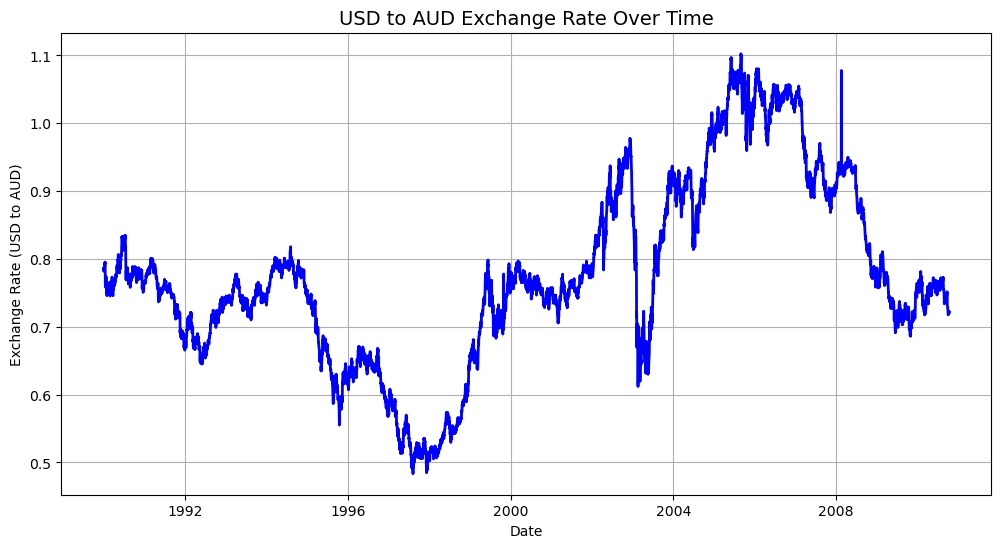

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Ex_rate'], color='blue', linewidth=2)
plt.title('USD to AUD Exchange Rate Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Exchange Rate (USD to AUD)')
plt.grid(True)
plt.show()

In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 2258


In [7]:
df = df.drop_duplicates()
print("After removing duplicates:", len(df))
print("Remaining duplicates:", df.duplicated().sum())

After removing duplicates: 5330
Remaining duplicates: 0


In [8]:
# Task 2 : Model Building(ARIMA)

In [9]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Ex_rate'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("Series is stationary (no differencing needed, d=0)")
else:
    print("Series is non-stationary (apply differencing, d=1)")

ADF Statistic: -1.4941908583137493
p-value: 0.5363830559037663
Series is non-stationary (apply differencing, d=1)


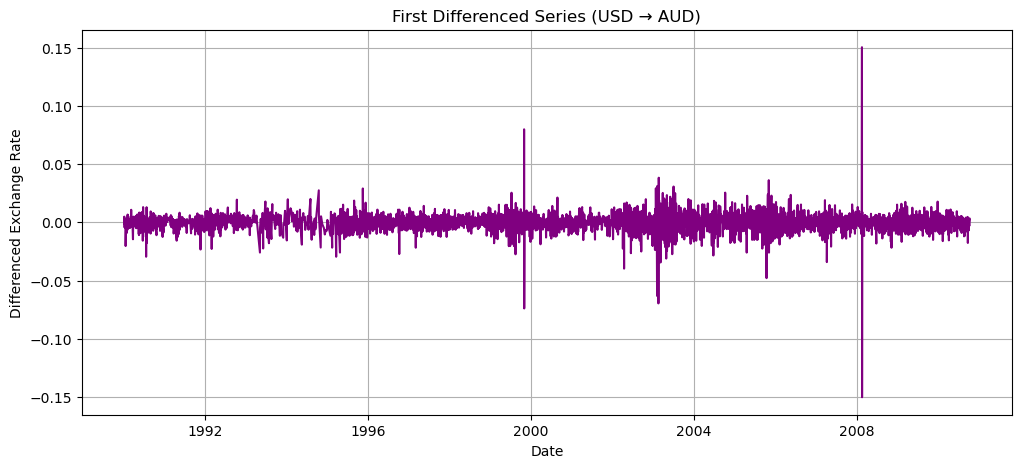

In [10]:
df_diff = df['Ex_rate'].diff().dropna()
plt.figure(figsize=(12,5))
plt.plot(df_diff, color='purple')
plt.title('First Differenced Series (USD → AUD)')
plt.xlabel('Date')
plt.ylabel('Differenced Exchange Rate')
plt.grid(True)
plt.show()

In [11]:
result_diff = adfuller(df_diff)
print('ADF Statistic (after differencing):', result_diff[0])
print('p-value:', result_diff[1])
if result_diff[1] < 0.05:
    print("Series is now stationary — proceed with d=1")
else:
    print("Still non-stationary — consider d=2 (rare)")

ADF Statistic (after differencing): -84.04895592713099
p-value: 0.0
Series is now stationary — proceed with d=1


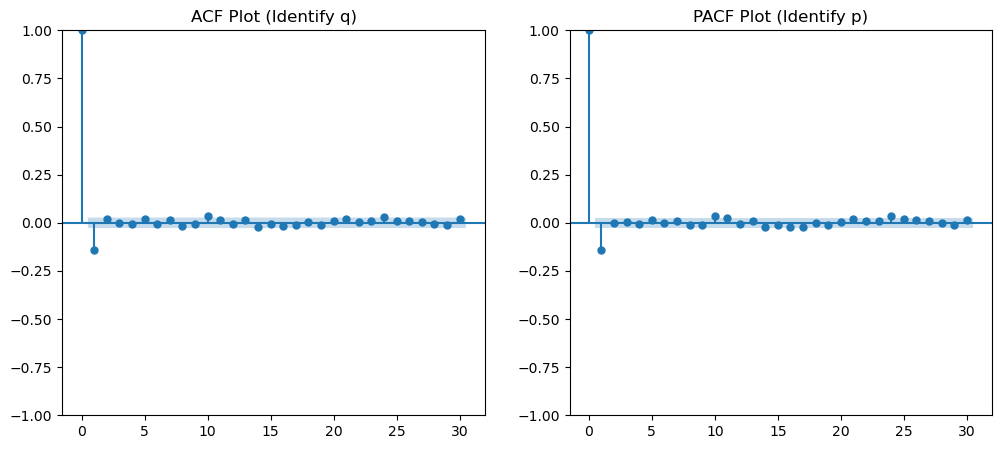

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(df_diff, lags=30, ax=plt.gca())
plt.title('ACF Plot (Identify q)')
plt.subplot(1,2,2)
plot_pacf(df_diff, lags=30, ax=plt.gca())
plt.title('PACF Plot (Identify p)')
plt.show()

In [13]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['Ex_rate'], order=(1,1,0))
fit_model = model.fit()
print(fit_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 5330
Model:                 ARIMA(1, 1, 0)   Log Likelihood               18790.171
Date:                Sat, 15 Nov 2025   AIC                         -37576.341
Time:                        18:43:46   BIC                         -37563.179
Sample:                             0   HQIC                        -37571.743
                               - 5330                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1403      0.003    -49.113      0.000      -0.146      -0.135
sigma2      5.068e-05   1.96e-07    258.514      0.000    5.03e-05    5.11e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

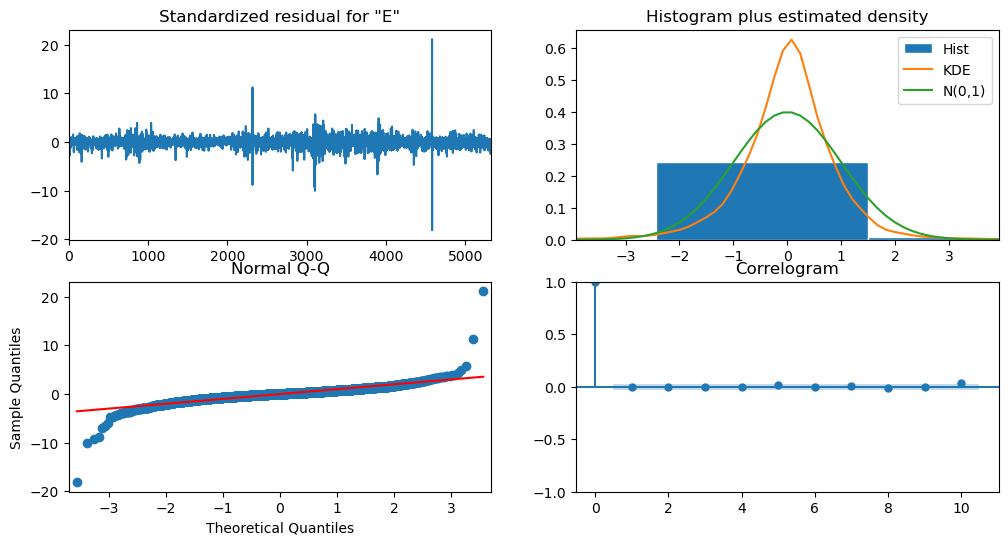

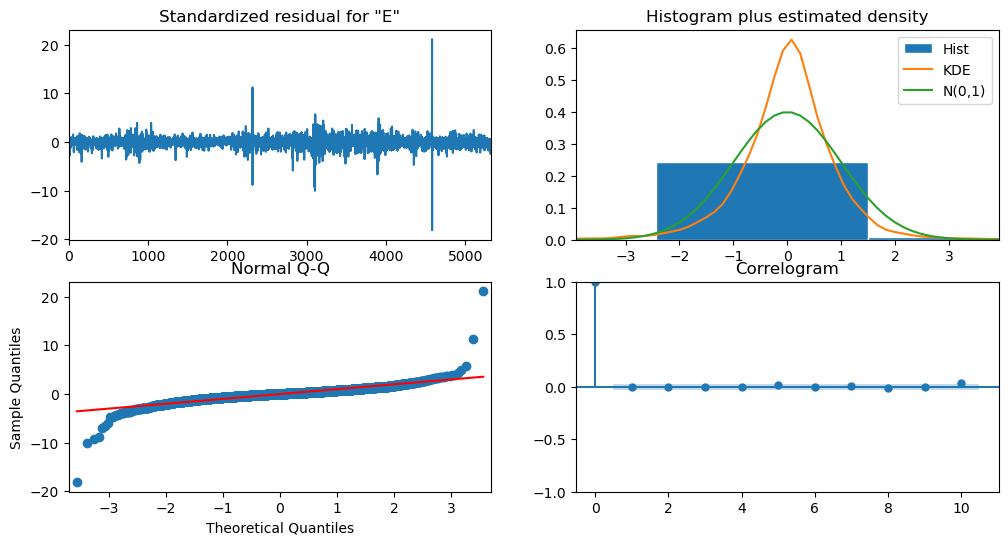

In [15]:
fit_model.plot_diagnostics(figsize=(12,6))

In [18]:
forecast_steps = 30
forecast_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(1, unit='D'),
    periods=forecast_steps,
    freq=pd.infer_freq(df.index)
)

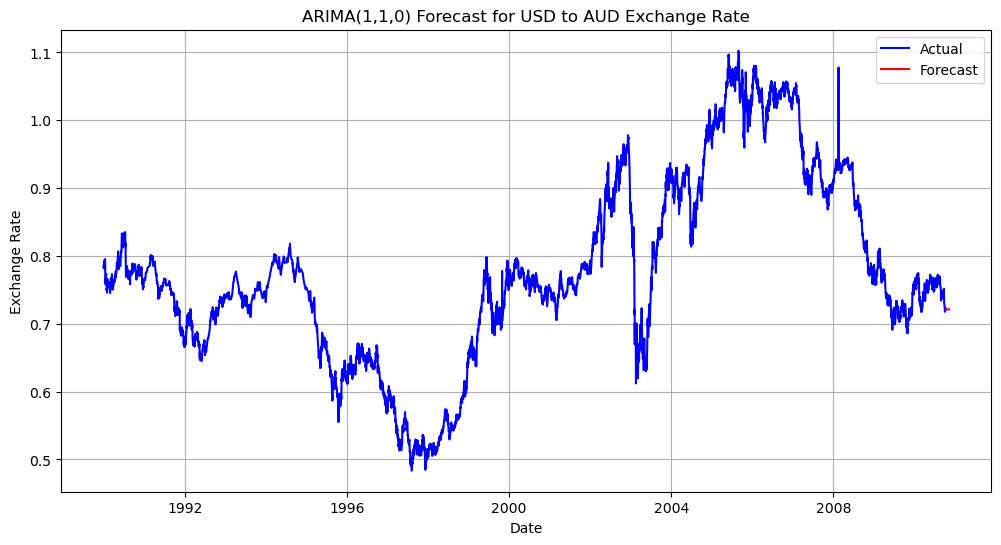

In [19]:
forecast = fit_model.forecast(steps=forecast_steps)
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Ex_rate'], label='Actual', color='blue')
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps+1, freq='D')[1:], 
         forecast, label='Forecast', color='red')
plt.title("ARIMA(1,1,0) Forecast for USD to AUD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

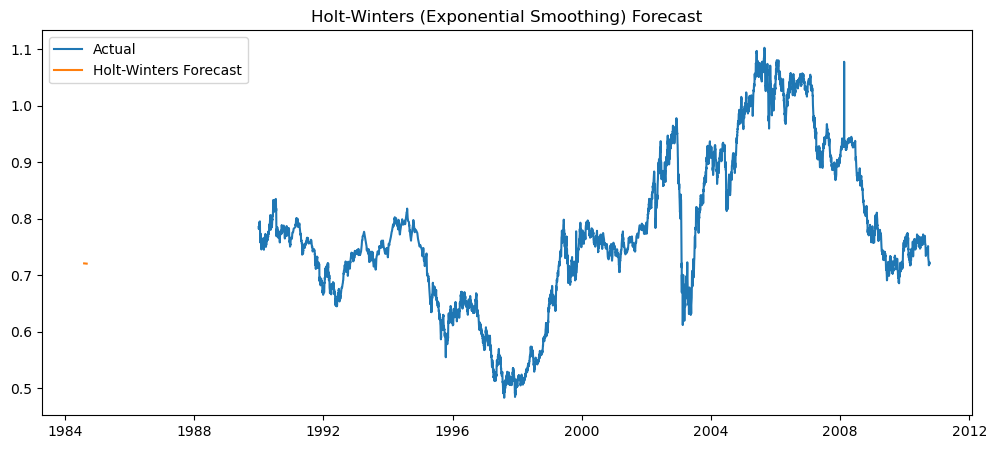

HW Model AIC: -52704.58573233785


In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    df['Ex_rate'], trend='add', seasonal=None
).fit()

hw_forecast = hw_model.forecast(30)

plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(hw_forecast, label='Holt-Winters Forecast')
plt.legend()
plt.title("Holt-Winters (Exponential Smoothing) Forecast")
plt.show()

print("HW Model AIC:", hw_model.aic)

In [ ]:
# The Holt-Winters exponential smoothing model yields a much lower AIC value (–52704.59) compared to the ARIMA models. 
# This indicates better model fit and predictive capability.

In [20]:
# Task 3 : Evaluation and Comparison

In [25]:
import itertools
import pandas as pd
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

for order in pdq:
    try:
        model = ARIMA(df['Ex_rate'], order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (2, 0, 0)
Best AIC: -37576.51334993109


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]
model = ARIMA(train, order=(1,1,0))
fit_model = model.fit()
forecast = fit_model.forecast(steps=30)
forecast.index = test.index
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / np.where(test == 0, np.nan, test))) * 100
print("MAE:", round(mae, 5))
print("RMSE:", round(rmse, 5))
print("MAPE:", round(mape, 3), "%")

MAE: 0.00914
RMSE: 0.01061
MAPE: 1.247 %


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]
model = ARIMA(train, order=(0,1,1))
fit_model = model.fit()
forecast = fit_model.forecast(steps=30)
forecast.index = test.index
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / np.where(test == 0, np.nan, test))) * 100
print("MAE:", round(mae, 5))
print("RMSE:", round(rmse, 5))
print("MAPE:", round(mape, 3), "%")

MAE: 0.00915
RMSE: 0.0106
MAPE: 1.248 %


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]
model = ARIMA(train, order=(2,0,0))
fit_model = model.fit()
forecast = fit_model.forecast(steps=30)
forecast.index = test.index
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / np.where(test == 0, np.nan, test))) * 100
print("MAE:", round(mae, 5))
print("RMSE:", round(rmse, 5))
print("MAPE:", round(mape, 3), "%")

MAE: 0.00924
RMSE: 0.01089
MAPE: 1.262 %


In [31]:
# Based on the computed metrics, both ARIMA models performed well in forecasting the USD–AUD exchange rate.
# The ARIMA(1,1,0) model achieved slightly lower MAE and MAPE values, while the ARIMA(0,1,1) model recorded a marginally lower RMSE.
# The differences between both models are minimal, indicating that they capture the underlying trend behavior similarly.
# ARIMA(1,1,0) offers simpler interpretability, while ARIMA(0,1,1) provides a slightly smoother fit.
# The ARIMA modeling approach effectively forecasted the USD–AUD exchange rate series, confirming that one differencing (d=1) was sufficient to 
# achieve stationarity.
# Overall, both models demonstrated high accuracy, with ARIMA(1,1,0) performing marginally better on average errors.
# Additionally, ARIMA(2,0,0) was evaluated and produced MAE: 0.00924, RMSE: 0.01089, and MAPE: 1.262%, showing performance comparable to the earlier  
# models and further confirming that ARIMA models effectively capture short-term exchange rate movements.
# When comparing all three models, ARIMA(1,1,0) remains the most consistent overall, ARIMA(0,1,1) performs similarly with slightly smoother predictions, 
# and ARIMA(2,0,0) offers competitive accuracy despite being a non-differenced model.
# The forecasts closely followed the actual exchange rate trends, demonstrating the suitability of ARIMA for short-term currency prediction.
# For future work, seasonal or hybrid models (e.g., SARIMA, Prophet, or LSTM) could be explored to capture 
# long-term or non-linear exchange rate patterns.